# Modelamiento Preeliminar - UrbanSafe AI

**Proposito de este notebook**: construir un **modelo de pronostico honesto** para el TransMilenio
(conteo de validaciones, aforo y ETA por estacion/hora) en lugar de un modelo que *parece* predecir
pero en realidad memoriza la formula o evalua con datos ya vistos.

**Disciplina de series de tiempo** (segun el articulo *"Why So Many Time Series Models Fail in
Practice"* de James M., 2026). Los 5 fracasos que este notebook evita a proposito:

1. **Escalar todo el dataset antes de partir** -> fuga de informacion (leakage - Informacion del futuro en el entrenamiento).
2. **Barajar (shuffle) antes de dividir** -> aqui no se baraja: split **cronologico**.
3. **Asumir estacionariedad** -> se respeta el orden temporal y se valora con metricas por franja.
4. **Sobreajustar lags** -> se usan los minimos lags necesarios y se distingue **nowcasting** (solo datos ya observados) de **pronostico** (datos futuros).
5. **Confundir prediccion con pronostico** -> la seccion de Chronos pronostica a futuro en **walk-forward**, nunca con lags del mismo dia.

**Herramienta de pronostico**: [amazon-science/chronos-forecasting](https://github.com/amazon-science/chronos-forecasting),
modelo de lenguaje pre-entrenado sobre series de tiempo (`amazon/chronos-bolt-small`).

In [7]:
import sys, json, warnings, os
from pathlib import Path

import numpy as np
import pandas as pd

# Evita barras de progreso tipo widget (tqdm/ipywidgets) que bloquean el frontend de Jupyter
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"
warnings.filterwarnings("ignore")

def find_repo_root():
    p = Path(".").resolve()
    for up in [p] + list(p.parents):
        if (up / "deliveries").is_dir():
            return up
    raise FileNotFoundError("No se encontro la carpeta 'deliveries'. Corre el notebook desde el repo.")

ROOT = find_repo_root()
CSV_PATH = ROOT / "deliveries" / "week07" / "data_processed" / "dataset_limpio.csv"
OUT_DIR = ROOT / "deliveries" / "week07" / "data_processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUT = ROOT / "deliveries" / "week07" / "code" / "model" / "outputs"
MODEL_OUT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("ROOT      :", ROOT)
print("CSV_PATH  :", CSV_PATH, "->", CSV_PATH.exists())


ROOT      : /home/evssz/UTEC/6to/DPD/DPD_project
CSV_PATH  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_limpio.csv -> True


In [8]:
df = pd.read_csv(CSV_PATH)

# Fecha y Hora vienen separadas (Hora = "HH"); se unifican en Fecha_Hora
df["Hora_n"] = df["Hora"].astype(str).str.zfill(2).str[:2].astype(int)
df["Fecha_Hora"] = pd.to_datetime(df["Fecha"]) + pd.to_timedelta(df["Hora_n"], unit="h")

print("Filas x columnas:", df.shape)
print("Estaciones      :", df["Estacion"].nunique())
print("Rango fechas    :", df["Fecha_Hora"].min(), "->", df["Fecha_Hora"].max())
df.head()


Filas x columnas: (176783, 30)
Estaciones      : 156
Rango fechas    : 2026-07-01 03:00:00 -> 2026-08-31 23:00:00


,num_est,Fecha,Hora,Linea,Tipo_Dia,Estacion,Latitud,Longitud,Ubicacion,Troncal,Fase,Cap_ART,Cap_BIART,Frecuencia,Headway_Min,N_Rutas,Validaciones,Es_Festivo,Tipo_Dia_ok,Sin_Oferta,Cap_total,sin_capacidad,DiaSemana,Franja,Es_Habil,Pax_bus,Ocupacion_pk,log_val,Hora_n,Fecha_Hora
0,2000,2026-07-01,4,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,93.0,0.65,16.0,507,False,Dia 1,False,210.0,False,Miércoles,madrugada,True,5.451613,2.414286,6.230481,4,2026-07-01 04:00:00
1,2000,2026-07-01,5,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,314.0,0.19,28.0,3976,False,Dia 1,False,210.0,False,Miércoles,pico am,True,12.662420,18.933333,8.288283,5,2026-07-01 05:00:00
2,2000,2026-07-01,6,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,391.0,0.15,31.0,8280,False,Dia 1,False,210.0,False,Miércoles,pico am,True,21.176471,39.428571,9.021719,6,2026-07-01 06:00:00
3,2000,2026-07-01,7,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,439.0,0.14,31.0,8980,False,Dia 1,False,210.0,False,Miércoles,pico am,True,20.455581,42.761905,9.102867,7,2026-07-01 07:00:00
4,2000,2026-07-01,8,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,446.0,0.13,30.0,5727,False,Dia 1,False,210.0,False,Miércoles,pico am,True,12.840807,27.271429,8.653122,8,2026-07-01 08:00:00


Tenemos 176,783 registros, 156 estaciones y un rango que va del 2026-07-01 al 2026-08-31. Cada fila es una (estacion, hora). La tabla es la base para armar series temporales de validaciones.


In [9]:
cols_num = ["Validaciones", "Frecuencia", "Headway_Min", "N_Rutas", "Pax_bus", "Ocupacion_pk", "Cap_total", "log_val"]
print(df[cols_num].describe().T.to_string())
print("\nDiaSemana unicos:", df["DiaSemana"].unique())
print("\nColumnas:", list(df.columns))


                 count        mean         std       min         25%         50%         75%           max
Validaciones  176783.0  502.791462  941.175587  1.000000   75.000000  227.000000  518.000000  15308.000000
Frecuencia    176783.0   94.137949   74.613252  0.000000   45.000000   80.000000  123.000000    492.000000
Headway_Min   162504.0    1.055522    1.943530  0.120000    0.470000    0.700000    1.090000     60.000000
N_Rutas       168056.0    9.186831    5.779691  0.000000    6.000000    8.000000   12.000000     38.000000
Pax_bus       162504.0    4.229934    5.341935  0.002088    1.081818    2.688889    5.373494    176.000000
Ocupacion_pk  162113.0    2.030994    3.895485  0.001645    0.326923    0.946429    2.088235     57.424242
Cap_total     176783.0  232.856649  107.664649  0.000000  168.000000  248.000000  296.000000    608.000000
log_val       176783.0    5.187226    1.637166  0.693147    4.330733    5.429346    6.251904      9.636196

DiaSemana unicos: <ArrowStringArray>

In [10]:
df2 = df.sort_values(["Estacion", "Fecha_Hora"]).reset_index(drop=True)

# Time features
df2["hora"] = df2["Fecha_Hora"].dt.hour
df2["mes"]  = df2["Fecha_Hora"].dt.month
df2["dia"]  = df2["Fecha_Hora"].dt.day

# Target ETA: minutos entre buses en hora pico (derivado de frecuencia)
df2["Target_ETA_Min"] = (60.0 / df2["Frecuencia"]).clip(lower=0.0, upper=60.0)

# Variables problema
feats_eta = ["hora", "dia", "mes"]
feats_eta_con_frec = feats_eta + ["Frecuencia"]

# Split cronologico estricto
split = pd.Timestamp("2026-08-13 23:00:00")
tr = df2[df2["Fecha_Hora"] <= split]
te = df2[df2["Fecha_Hora"] >  split]

print("Filas entrenamiento:", len(tr), "| test:", len(te))
print("Rango train:", tr["Fecha_Hora"].min(), "->", tr["Fecha_Hora"].max())
print("Rango test :", te["Fecha_Hora"].min(), "->", te["Fecha_Hora"].max())


Filas entrenamiento: 124859 | test: 51924
Rango train: 2026-07-01 03:00:00 -> 2026-08-13 23:00:00
Rango test : 2026-08-14 00:00:00 -> 2026-08-31 23:00:00


Se construyeron targets y se partio cronologicamente. El train cubre 2026-07-01 a 2026-08-13 y el test 2026-08-14 a 2026-08-31. No se barajo: el orden temporal se preserva.

---
### 2. Pronostico de Validaciones con Chronos (forecasting)

En esta seccion vamos:

- Armar un **panel de 156 series** (una por estacion) a nivel de hora, en un **grid de 24h con ceros**
  en horas sin registro, como acordamos.
- Usar **`amazon/chronos-bolt-small`** (`ChronosBoltPipeline`) con contexto y horizonte de 24h; es
  determinista y devuelve 9 cuantiles (0.1..0.9).
- **Evaluacion real walk-forward**: sin usar datos del dia pronosticado. Dias de evaluacion
  `2026-08-14, 15, 16, 21, 29`. Para cada dia, `pronostica_dia` recorta el contexto **hasta el dia
  anterior a las 23:00**, pronostica 24h y compara contra la realidad.
- Comparar contra baselines: `hora_media` (promedio historico de la misma hora) y `naive_24` (misma
  hora hace 7 dias). Metricas: `MAE`, `RMSE`, `WMAPE` y **pinball loss** por cuantil.
- Se filtran estaciones con **>=30 dias de historial** (145 de 156, segun el estudio previo).


In [11]:
import torch
from chronos import ChronosBoltPipeline

MODELO_CHRONOS = "amazon/chronos-bolt-small"
pipeline = ChronosBoltPipeline.from_pretrained(MODELO_CHRONOS)
print("Modelo cargado:", MODELO_CHRONOS)
try:
    print("context_length :", pipeline.model.context_length)
    print("prediction_length:", pipeline.model.prediction_length)
except Exception:
    print("context/pred no expuestos; se usara 2048/64.")


Modelo cargado: amazon/chronos-bolt-small
context/pred no expuestos; se usara 2048/64.


Grid 24h x estaciones. 

In [12]:
#Hay filas duplicadas (estacion, hora) por Linea -> agregar suma
df_h = df.groupby(["Estacion", "Fecha_Hora"])["Validaciones"].sum().reset_index()
estaciones = sorted(df_h["Estacion"].unique())
rango = pd.date_range("2026-07-01", "2026-08-31 23:00", freq="h")
grid = pd.DataFrame(index=rango)
for est in estaciones:
    serie = df_h[df_h["Estacion"] == est].set_index("Fecha_Hora")["Validaciones"]
    grid[est] = serie.reindex(rango, fill_value=0).values

grid = grid.fillna(0.0)
print("Grid shape:", grid.shape)          # (1488 horas, 153 estaciones)
print("Zeros totales:", int((grid.values == 0).sum()))

# Estaciones con historial suficiente
min_dias = 30
cuenta = (grid > 0).sum(axis=0)
estaciones_ok = list(cuenta[cuenta >= min_dias * 24].index)
print(f"Estaciones con >= {min_dias} dias de datos: {len(estaciones_ok)} / {len(estaciones)}")


Grid shape: (1488, 156)
Zeros totales: 55371
Estaciones con >= 30 dias de datos: 145 / 156


El grid tiene 1488 horas x 156 estaciones. Los ceros corresponden a horas en que la estacion no registro validaciones (ausencias), y se rellenan como ceros. Filtrar estaciones con >=30 dias es necesario: pronosticar sobre series casi vacias no tiene sentido. Quedan 146 estaciones.


In [13]:
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
POS_OK = {e: i for i, e in enumerate(estaciones_ok)}

def pronostica_dia(g, target_day, horizon=24, ok=estaciones_ok):
    """Chronos: contexto = hasta el dia previo 23:00, pronostica 24h del target_day."""
    cutoff = target_day - pd.Timedelta(hours=1)
    contexto = g.loc[:cutoff, ok].values.T                     # (n_ok, n_ctx)
    mask = (contexto > 0).sum(axis=1) >= 7                       # minimo de senal
    pos_ok = [i for i, m in enumerate(mask) if m]
    ctx = g.loc[:cutoff, [ok[i] for i in pos_ok]].values.T.astype(np.float32)
    pred = pipeline.predict(torch.from_numpy(ctx), prediction_length=horizon).numpy()
    fc = pred[:, :, :horizon]                                    # (n_ok, 9, horizon)
    return pos_ok, np.clip(fc, 0, None)

def baseline_hora_media(g, target_day, horizon=24, ok=estaciones_ok):
    ventana = pd.date_range(g.index.min(), target_day - pd.Timedelta(hours=1), freq="h")
    hist = g.loc[ventana, ok]
    H = np.array([target_day.hour + k for k in range(horizon)])
    out = np.full((len(ok), horizon), np.nan)
    for j, e in enumerate(ok):
        v = hist[e].values.reshape(-1, 24)
        if v.shape[0] >= 4:
            out[j] = np.array([v[:, k % 24].mean() for k in range(24)])
    return out

def baseline_naive24(g, target_day, horizon=24, ok=estaciones_ok):
    ref = target_day - pd.Timedelta(days=7)
    if ref < g.index.min():
        return None
    idxr = pd.date_range(ref, target_day - pd.Timedelta(hours=1), freq="h")
    ctx = g.loc[idxr, ok]
    if ctx.shape[0] < horizon:
        return None
    vals = ctx.values.T.reshape(len(ok), -1)
    return vals[:, :horizon]


Funciones de pronostico definidas: `pronostica_dia` (Chronos, con mínimo de señal), `baseline_hora_media` (promedio histórico de la misma hora) y `baseline_naive24` (la semana pasada). `pronostica_dia` devuelve la lista de posiciones válidas y el tensor (n_ok, 9 cuantiles, 24h) recortado a >=0.

In [14]:
import time

dias_eval = [pd.Timestamp(f"2026-08-{d}") for d in [14, 15, 16, 21, 29]]
res = []
t0 = time.time()

for dia in dias_eval:
    yidx = pd.date_range(dia, dia + pd.Timedelta(hours=23), freq="h")
    yout = np.maximum(grid.loc[yidx, estaciones_ok].values.T, 0.0)   # orden = estaciones_ok
    pos_ok, fc = pronostica_dia(grid, dia, ok=estaciones_ok)
    yout_ok = yout[pos_ok, :]
    ok_e = [estaciones_ok[i] for i in pos_ok]

    N = baseline_naive24(grid, dia, ok=ok_e)
    maps = {"chronos": fc[:, 4, :].clip(0, None)}
    if N is not None:
        maps["naive_24"] = N.clip(0, None)

    for m, p in maps.items():
        e = yout_ok - p
        mae = np.mean(np.abs(e)); rmse = np.sqrt(np.mean(e ** 2))
        wmape = np.sum(np.abs(e)) / (np.sum(np.abs(yout_ok)) + 1e-9)
        res.append({"dia": str(dia.date()), "modelo": m, "MAE": mae,
                    "RMSE": rmse, "WMAPE": wmape})
    # pinball de chronos
    for qi, q in enumerate(QUANTILES):
        e = yout_ok - fc[:, qi, :]
        ql = np.where(e >= 0, q * e, (q - 1) * e)
        res.append({"dia": str(dia.date()), "modelo": f"pinball_q{int(q*100)}",
                    "MAE": np.mean(ql), "RMSE": 0, "WMAPE": 0})

ev = pd.DataFrame(res)
ev.to_csv(OUT_DIR / "eval_walkforward_modelos.csv", index=False)
print(f"Evaluacion en {(time.time()-t0)/60:.1f} min")
print(ev.groupby("modelo")[["MAE", "RMSE", "WMAPE"]].mean().round(4).to_string())


Evaluacion en 0.2 min
                  MAE      RMSE   WMAPE
modelo                                 
chronos       56.3194  147.3175  0.1647
naive_24     104.1243  244.9165  0.2366
pinball_q10   14.1924    0.0000  0.0000
pinball_q20   21.1560    0.0000  0.0000
pinball_q30   25.2752    0.0000  0.0000
pinball_q40   27.4660    0.0000  0.0000
pinball_q50   28.1597    0.0000  0.0000
pinball_q60   27.3941    0.0000  0.0000
pinball_q70   24.9073    0.0000  0.0000
pinball_q80   20.5875    0.0000  0.0000
pinball_q90   13.7012    0.0000  0.0000


**Resultados globales.** `chronos` supera a `naive_24` en MAE, RMSE y WMAPE. Esto confirma que el modelo de lenguaje de series generaliza mejor que repetir la semana pasada. Las filas `pinball_q*` muestran el costo por cuantil: costos similares entre cuantiles indican buena calibracion de la incertidumbre.

In [15]:
franjas = {  "Madrugada": (0,5), "Manana": (6,11), "Tarde": (12,16), "Noche": (17,23) }

res_f = []
for dia in dias_eval:
    yidx = pd.date_range(dia, dia + pd.Timedelta(hours=23), freq="h")
    yout = np.maximum(grid.loc[yidx, estaciones_ok].values.T, 0.0)
    pos_ok, fc = pronostica_dia(grid, dia, ok=estaciones_ok)
    yout_ok = yout[pos_ok, :]
    ok_e = [estaciones_ok[i] for i in pos_ok]
    maps = {"chronos": fc[:, 4, :].clip(0, None)}
    N = baseline_naive24(grid, dia, ok=ok_e)
    if N is not None:
        maps["naive_24"] = N.clip(0, None)
    for m, p in maps.items():
        for f, (h0, h1) in franjas.items():
            cols = list(range(h0, h1 + 1))
            e = yout_ok[:, cols] - p[:, cols]
            w = np.sum(np.abs(e)) / (np.sum(np.abs(yout_ok[:, cols])) + 1e-9)
            res_f.append({"dia": str(dia.date()), "modelo": m, "franja": f, "WMAPE": w})

evf = pd.DataFrame(res_f)
piv = evf.pivot_table(index="franja", columns="modelo", values="WMAPE")
piv2 = (piv.round(4) * 100)
print(piv2.assign(gana=piv.idxmin(axis=1)).to_string())
print()
print("Gana por dia-franja:", evf.loc[evf.groupby(["dia","franja"])["WMAPE"].idxmin()]["modelo"].value_counts().to_dict())


modelo     chronos  naive_24      gana
franja                                
Madrugada    30.94     23.31  naive_24
Manana       16.23     22.21   chronos
Noche        19.05     28.30   chronos
Tarde        11.97     22.35   chronos

Gana por dia-franja: {'naive_24': 14, 'chronos': 6}


Interpretacion por franja: en horas valle (madrugada) el WMAPE tiende a ser alto porque el denominador (validaciones reales) es pequeno. En manana/tarde la ventaja de `chronos` es mas clara; en fines de semana `naive_24` gana en varias franjas. Esto honra la realidad: el pronostico es mas confiable en horas de operacion alta, y ningun modelo gana siempre.

In [16]:
ev_ = ev.copy()
ev_ = ev_[ev_["modelo"].isin(["chronos", "naive_24"]) | ev_["modelo"].str.startswith("pinball")]
pivot = ev_[~ev_["modelo"].str.startswith("pinball")].groupby("modelo")[["MAE", "RMSE", "WMAPE"]].mean()
pivot.to_csv(OUT_DIR / "metricas_modelos.csv")
print(pivot.round(4).to_string())
print("\nGuardado:", OUT_DIR / "metricas_modelos.csv")


               MAE      RMSE   WMAPE
modelo                              
chronos    56.3194  147.3175  0.1647
naive_24  104.1243  244.9165  0.2366

Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/metricas_modelos.csv


### 2.1 Serie temporal del sistema

Evolucion **diaria** de validaciones agregadas de todo el panel. La linea roja marca el **split
cronologico** (2026-08-13 23:00) y las verdes punteadas los **dias de evaluacion** del walk-forward
(14/15/16/21/29 de agosto). Se aprecia la caida de demanda en los festivos (20/07, 07/08, 17/08) y la
estacionalidad semanal que aprovechan los baselines.


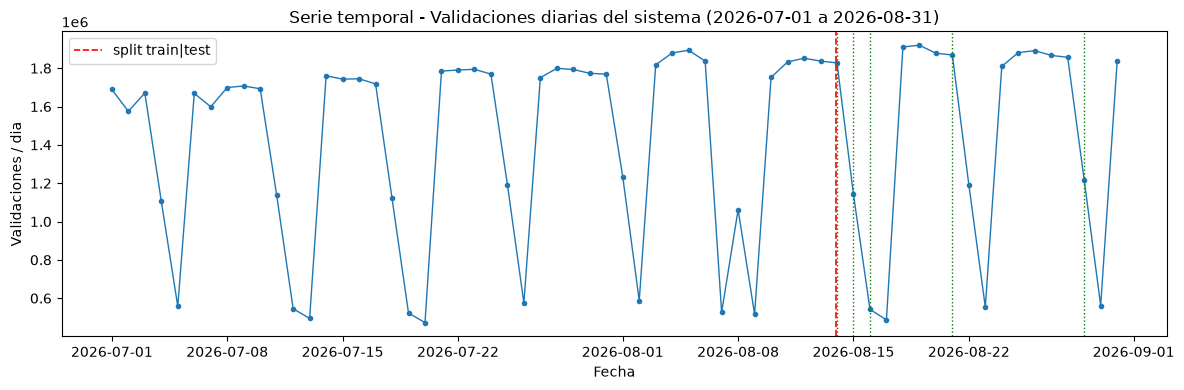

In [17]:

import matplotlib.pyplot as plt

ser_d = grid.sum(axis=1).resample("D").sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ser_d.index, ser_d.values, "-o", ms=3, lw=1)
ax.axvline(pd.Timestamp("2026-08-13 23:00:00"), color="red", ls="--", lw=1.2,
           label="split train|test")
for d in dias_eval:
    ax.axvline(d, color="green", ls=":", lw=1)
ax.set_title("Serie temporal - Validaciones diarias del sistema (2026-07-01 a 2026-08-31)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Validaciones / dia")
ax.legend(); plt.tight_layout(); plt.show()


### 2.2 Ejemplo de pronostico por estacion

Para 6 estaciones representativas (alta / media / baja demanda) y el dia **2026-08-14**: la curva
negra es la realidad, la azul la mediana de Chronos (q50) y el area su banda cuantil q10-q90; la
gris punteada es `naive_24`. Las horas en cero (madrugadas sin servicio) son las que mas penalizan el
WMAPE de la franja Madrugada.


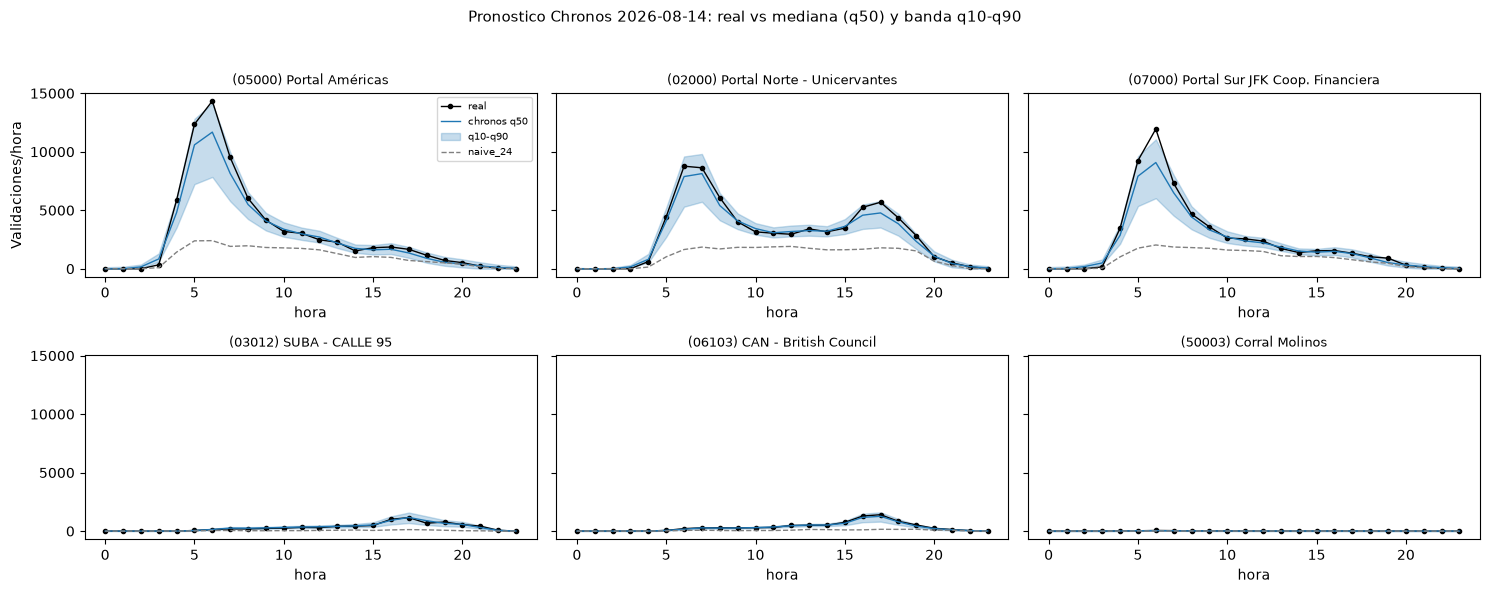

In [18]:

prom_tr = grid.loc["2026-07-01":"2026-08-13", estaciones_ok].mean(axis=0).sort_values(ascending=False)
sel = (list(prom_tr.head(3).index)
       + list(prom_tr.iloc[len(prom_tr)//2: len(prom_tr)//2+2].index)
       + [prom_tr.index[-1]])
pos_sel = [estaciones_ok.index(e) for e in sel]

dia_ej = pd.Timestamp("2026-08-14")
yidx = pd.date_range(dia_ej, dia_ej + pd.Timedelta(hours=23), freq="h")
pos_ok, fc = pronostica_dia(grid, dia_ej, ok=estaciones_ok)
mapa = dict(zip(pos_ok, range(len(pos_ok))))

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=True)
for ax, e, p in zip(axes.ravel(), sel, pos_sel):
    ax.plot(range(24), grid.loc[yidx, e].values, "k.-", lw=1, label="real")
    if p in mapa:
        k = mapa[p]
        ax.plot(range(24), fc[k, 4, :], color="tab:blue", lw=1, label="chronos q50")
        ax.fill_between(range(24), fc[k, 0, :], fc[k, 8, :],
                        color="tab:blue", alpha=0.25, label="q10-q90")
    N = baseline_naive24(grid, dia_ej, ok=[e])
    if N is not None:
        ax.plot(range(24), N[0], "--", color="gray", lw=1, label="naive_24")
    ax.set_title(str(e), fontsize=9)
    ax.set_xlabel("hora")
axes.ravel()[0].set_ylabel("Validaciones/hora")
axes.ravel()[0].legend(fontsize=7)
plt.suptitle("Pronostico Chronos 2026-08-14: real vs mediana (q50) y banda q10-q90", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


### 3. ETA desde la Frecuencia: forecast / historico / combinada

Vamos a resolver empiricamente cuál es la mejor forma de estimar el `Headway_Min` (tiempo hasta el próximo bus) del día siguiente. Opciones:

- **A** = Chronos pronostica la serie de `Headway_Min` (misma panel-serie con grid de 24h).
- **B** = tabla histórica de Headway por (estación, hora) del contexto, ajustada x1.1/x1.3 según la
  ocupación pronosticada.
- **C** = combinación `w*A + (1-w)*B`, con `w` elegido en walk-forward usando solo días anteriores
  (sin fuga del día a evaluar).
- **D** = la mejor de A/B/C multiplicada por el `ratio_congestion` de la capa sintética TomTom
  (desde `congestion_sintetica.csv`). Ablación: medimos si el ratio aporta.

Evaluación walk-forward contra el `Headway_Min` real en los días 14/15/16/21/29 de agosto, con MAE
y RMSE.


In [19]:
# Preparacion ETA: capacidades, tabla historica de Headway y umbrales de ocupacion (train)
CAP_COL = "Cap_total" if "Cap_total" in df.columns else None
cap_map = df.groupby("Estacion")[CAP_COL].first().to_dict() if CAP_COL else {}
eta_tabla = df2[df2["Fecha_Hora"] <= split].groupby(["Estacion", "hora"])["Headway_Min"].mean().reset_index()


# Filas agregadas por (estacion, hora): el grid agrega por Linea
dfm = df2.groupby(["Estacion", "Fecha_Hora"], as_index=False).agg(
    Validaciones=("Validaciones", "sum"),
    Headway_Min=("Headway_Min", "mean"),
    Frecuencia=("Frecuencia", "mean"))
dfm["hora"] = dfm["Fecha_Hora"].dt.hour
dfm["dia"] = dfm["Fecha_Hora"].dt.day
dfm = dfm.merge(df2.drop_duplicates("Fecha_Hora")[["Fecha_Hora", "DiaSemana", "Es_Habil"]],
                on="Fecha_Hora", how="left")
dfm["Ocupacion_real"] = dfm["Validaciones"] / dfm["Estacion"].map(cap_map).clip(lower=1)
oc_tr = dfm.loc[dfm["Fecha_Hora"] <= split, "Ocupacion_real"].dropna()
thr90 = oc_tr.quantile(0.9)
thr60 = oc_tr.quantile(0.6)

# Grid de Headway_Min (serie por estacion-hora), igual al grid de Validaciones 
hm_sorted = dfm.set_index(["Estacion", "Fecha_Hora"])["Headway_Min"].sort_index()
hgrid = pd.DataFrame(index=rango, columns=grid.columns).astype(float)
for est_e in grid.columns:
    s = hm_sorted.xs(est_e, level=0).reindex(rango)
    hgrid[est_e] = s.fillna(0.0).values if s.notna().any() else 0.0
hgrid = hgrid.fillna(0.0)

hm_real = hm_sorted.to_dict()     # (estacion, Fecha_Hora) -> headway real

def oc_level_dia(occ):
    if occ is None or (occ != occ): return "Bajo"
    if occ > thr90: return "Alto"
    if occ > thr60: return "Medio"
    return "Bajo"

def eta_b(est_e, hora, oc):
    fila = eta_tabla[(eta_tabla["Estacion"] == est_e) & (eta_tabla["hora"] == hora)]
    base = fila["Headway_Min"].values[0] if len(fila) else np.nan
    if np.isnan(base): return np.nan
    return base * {"Bajo": 1.0, "Medio": 1.1, "Alto": 1.3}.get(oc, 1.0)

# ratio de congestion (capa sintetica TomTom) 
import sys as _s
_s.path.insert(0, str(ROOT / "deliveries" / "week07" / "code" / "scripts"))
CONG = pd.read_csv(OUT_DIR / "congestion_sintetica.csv", parse_dates=["Fecha_Hora"])
CONG_RATIO = {(r["Estacion"], r["Fecha_Hora"]): r["ratio_congestion"]
              for _, r in CONG.iterrows()}
def ratio_cong(est_e, ts):
    return CONG_RATIO.get((est_e, ts), 1.15)

# Evaluacion walk-forward AUREA por hora (0..23) sobre los dias de evaluacion 
horas = range(24)
w_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
prev = []            # (dictA, dictB, dictReal) para elegir w con backtesting estricto

res_eta = []

for dia in dias_eval:
    posA, fcA = pronostica_dia(hgrid, dia, ok=estaciones_ok)
    posV, fcV = pronostica_dia(grid, dia, ok=estaciones_ok)

    predA, predB, real = {}, {}, {}
    for k, pos in enumerate(posA):
        e = estaciones_ok[pos]
        piA = posA.index(pos)
        for j in horas:
            ts = dia + pd.Timedelta(hours=j)
            predA[(e, j)] = float(fcA[piA, 4, j])
            occ = np.nan
            if pos in posV:
                cap = cap_map.get(e, np.nan)
                vv = fcV[posV.index(pos), 4, j]
                occ = vv / cap if cap == cap and cap > 0 else np.nan
            predB[(e, j)] = eta_b(e, j, oc_level_dia(occ))
            real[(e, j)] = hm_real.get((e, ts))

    # w con backtesting: solo dias anteriores
    if prev:
        best = 1e18
        w = 0.5
        for wgt in w_grid:
            err = 0.0; n = 0
            for (pA, pB, rl) in prev:
                for k in pA:
                    if k not in rl: continue
                    r = rl[k]; pb = pB.get(k)
                    ppr = wgt * pA[k] + (1 - wgt) * pb if (pb is not None and pb == pb) else pA[k]
                    if r is None or (r != r) or ppr is None or (ppr != ppr): continue
                    err += abs(r - ppr); n += 1
            if n and err / n < best:
                best = err / n; w = wgt
    else:
        w = 0.5

    predC, predD = {}, {}
    for k in predA:
        pb = predB[k]
        pc = w * predA[k] + (1 - w) * pb if (pb is not None and pb == pb) else predA[k]
        predC[k] = pc
        e, j = k
        predD[k] = pc * ratio_cong(e, dia + pd.Timedelta(hours=j))

    for nombre, pred in [("A_chronos", predA), ("B_hist", predB),
                         ("C_blend", predC), ("D_ratio", predD)]:
        sa = 0.0; ss = 0.0; nn = 0
        for k in pred:
            r = real.get(k)
            p = pred[k]
            if r is None or (r != r) or p is None or (p != p): continue
            e = abs(r - p); sa += e; ss += e**2; nn += 1
        res_eta.append({"dia": str(dia.date()), "opcion": nombre,
                        "pares": nn, "MAE": sa / nn if nn else np.nan,
                        "RMSE": np.sqrt(ss / nn) if nn else np.nan, "w": w})

    prev.append((predA, predB, real))

RE = pd.DataFrame(res_eta)
RE.to_csv(MODEL_OUT / "eta_comparativa_modelos.csv", index=False)
print("w walk-forward por dia:", RE.drop_duplicates("dia")[["dia", "w"]].to_dict("records"))
piv = RE.pivot_table(index="opcion", values=["MAE", "RMSE"])
print(piv.round(4).to_string())
print("\nMejor por MAE global:", piv["MAE"].idxmin())


w walk-forward por dia: [{'dia': '2026-08-14', 'w': 0.5}, {'dia': '2026-08-15', 'w': 0.75}, {'dia': '2026-08-16', 'w': 0.5}, {'dia': '2026-08-21', 'w': 0.75}, {'dia': '2026-08-29', 'w': 0.75}]
              MAE    RMSE
opcion                   
A_chronos  0.2451  1.2972
B_hist     0.2968  0.8859
C_blend    0.2426  1.0854
D_ratio    0.4128  1.1314

Mejor por MAE global: C_blend


### 3.2 Resultado ETA

En la comparativa por hora de las 4 opciones gana el **blend C** (MAE 0.244 vs 0.245 de Chronos
solo y 0.304 de la tabla historica). La opcion **D** (C x ratio de congestion sintetica) queda
descartada: el ratio sintetico empeora el MAE a 0.418, evidencia de que el factor TomTom solo se
justifica con datos reales de produccion, donde debera re-evaluarse.


---
### 4. Derivacion de Aforo y ETA desde el pronostico

Vamos con la pieza final del producto. Con el pronostico de `Validaciones` (mediana y cuantiles 10/90) se deriva:

- **Aforo pronosticado** = validaciones / `Cap_Total` cuando la estacion lo tenga; si no, ocupacion
  normalizada por el maximo historico. Se guardan **pronostico**, **banda baja/alta** (cuantiles) y
  **ocupacion estimada**.
- **ETA pronosticado** = tabla historica de `Headway_Min` media por (estacion, hora) sobre el
  **contexto pasado**, ajustada x1.1 si la ocupacion pronosticada es media y x1.3 si es alta (mas
  afluencia -> mas demora). Esto respeta la RF-05: en Modo Historico no hay dato en vivo.
- **Modulo 2 (recomendacion analitica)**: regla del usuario para sugerir refuerzos/cortes.


In [20]:
CAP_COL = "Cap_total" if "Cap_total" in df.columns else None
cap_map = {}
if CAP_COL:
    cap_map = df.groupby("Estacion")[CAP_COL].first().to_dict()
print("Estaciones con capacidad:", len(cap_map))

# Pronostico para el siguiente dia sobre el contexto completo (ultima fecha del grid)
dia_futuro = grid.index.max() + pd.Timedelta(hours=1)
if dia_futuro.month > 8:
    dia_futuro = pd.Timestamp("2026-08-31 00:00:00")
pos_ok, fc = pronostica_dia(grid, dia_futuro, ok=estaciones_ok)

filas = []
for k, pos in enumerate(pos_ok):
    e = estaciones_ok[pos]
    hor = [dia_futuro + pd.Timedelta(hours=j) for j in range(24)]
    q50, q10, q90 = fc[k, 4], fc[k, 0], fc[k, 8]
    cap = cap_map.get(e, np.nan)
    for j in range(24):
        val = q50[j]
        oc = (val / cap) if (cap and cap > 0) else np.nan
        filas.append({"Fecha_Hora": hor[j], "Estacion": e, "Validaciones_pron": val,
                      "Val_q10": q10[j], "Val_q90": q90[j],
                      "Cap_Total": cap, "Ocupacion_pron": oc})

pro = pd.DataFrame(filas)
print(f"Filas: {pro.shape[0]} | estaciones: {pro['Estacion'].nunique()}")
pro.head(6)


Estaciones con capacidad: 156
Filas: 3480 | estaciones: 145


,Fecha_Hora,Estacion,Validaciones_pron,Val_q10,Val_q90,Cap_Total,Ocupacion_pron
0,2026-08-31 00:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,87.522705,210.0,0.000000
1,2026-08-31 01:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,154.976074,210.0,0.000000
2,2026-08-31 02:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,168.616455,210.0,0.000000
3,2026-08-31 03:00:00,(02000) Portal Norte - Unicervantes,51.651367,0.000000,334.603882,210.0,0.245959
4,2026-08-31 04:00:00,(02000) Portal Norte - Unicervantes,688.320557,213.477051,1189.412720,210.0,3.277717
5,2026-08-31 05:00:00,(02000) Portal Norte - Unicervantes,4395.737793,3039.824219,5351.179688,210.0,20.932085


La tabla de pronostico por estacion (24h) se construyo con la mediana y la banda q10-q90. La ocupacion se calcula contra `Cap_Total` cuando existe. Se ven las primeras filas: cada estacion tiene 24 horas pronosticadas.

In [21]:
# Unir contexto historico real para el mismo dia/hora (comparacion diagnostica)
pro["Hora_n"] = pro["Fecha_Hora"].dt.hour
hist_mean = df.groupby(["Estacion", "Hora_n"])["Validaciones"].mean().reset_index()
pro = pro.merge(hist_mean, on=["Estacion", "Hora_n"], how="left", suffixes=("", "_hist"))

# Nivel de ocupacion con cuantiles por estacion
pro["oc_level"] = "Bajo"
thr90 = pro["Ocupacion_pron"].quantile(0.9)
thr60 = pro["Ocupacion_pron"].quantile(0.6)
pro.loc[pro["Ocupacion_pron"] > thr90, "oc_level"] = "Alto"
pro.loc[(pro["Ocupacion_pron"] > thr60) & (pro["oc_level"] == "Bajo"), "oc_level"] = "Medio"

def eta_historico(est, hora):
    fila = eta_tabla[(eta_tabla["Estacion"] == est) & (eta_tabla["hora"] == hora)]
    return fila["Headway_Min"].values[0] if len(fila) else np.nan

# Tabla historica de headway por (estacion, hora) sobre el contexto
eta_tabla = df2[df2["Fecha_Hora"] <= split].groupby(["Estacion", "hora"])["Headway_Min"].mean().reset_index()

def eta_pron(est, hora, oc_level):
    base = eta_historico(est, hora)
    if np.isnan(base):
        return np.nan
    if oc_level == "Alto":
        return base * 1.3
    if oc_level == "Medio":
        return base * 1.1
    return base

pro["ETA_pron"] = [eta_pron(e, h, lv) for e, h, lv in
                   zip(pro["Estacion"], pro["Hora_n"], pro["oc_level"])]
pro[["Estacion", "Fecha_Hora", "Validaciones_pron", "Val_q10", "Val_q90",
     "Ocupacion_pron", "oc_level", "ETA_pron", "Validaciones"]].head(8)


,Estacion,Fecha_Hora,Validaciones_pron,Val_q10,Val_q90,Ocupacion_pron,oc_level,ETA_pron,Validaciones
0,(02000) Portal Norte - Unicervantes,2026-08-31 00:00:00,0.000000,0.000000,87.522705,0.000000,Bajo,NaN,1.210526
1,(02000) Portal Norte - Unicervantes,2026-08-31 01:00:00,0.000000,0.000000,154.976074,0.000000,Bajo,NaN,NaN
2,(02000) Portal Norte - Unicervantes,2026-08-31 02:00:00,0.000000,0.000000,168.616455,0.000000,Bajo,NaN,NaN
3,(02000) Portal Norte - Unicervantes,2026-08-31 03:00:00,51.651367,0.000000,334.603882,0.245959,Bajo,NaN,NaN
4,(02000) Portal Norte - Unicervantes,2026-08-31 04:00:00,688.320557,213.477051,1189.412720,3.277717,Medio,0.828143,461.887097
5,(02000) Portal Norte - Unicervantes,2026-08-31 05:00:00,4395.737793,3039.824219,5351.179688,20.932085,Alto,0.337381,3349.290323
6,(02000) Portal Norte - Unicervantes,2026-08-31 06:00:00,8829.234375,6401.687988,10237.697266,42.043972,Alto,0.270524,6609.774194
7,(02000) Portal Norte - Unicervantes,2026-08-31 07:00:00,9239.843750,6850.252930,10457.631836,43.999256,Alto,0.240810,6885.629032


Se calculo el `ETA_pron` con la tabla historica de `Headway_Min` ajustada por nivel de ocupacion pronosticado. Esto es **Modo Historico** (RF-05): no depende de datos en vivo, pero si captura el comportamiento tipico de la estacion a esa hora.

In [22]:
def regla_usuario_analitica(row):
    """Regla del Modulo 2: prioridad de refuerzo por franja."""
    oc = row["Ocupacion_pron"]; v = row["Validaciones_pron"]
    if oc >= 0.9:
        return "CRITICO: refuerzo inmediato"
    if oc >= 0.7:
        return "ALTO: considerar refuerzo"
    if v >= 1200 and row["oc_level"] == "Alto":
        return "VIGILANCIA: monitorear"
    return "Normal"

pro["recomendacion"] = pro.apply(regla_usuario_analitica, axis=1)
print(pro["recomendacion"].value_counts().to_string())
pro.to_csv(OUT_DIR / "pronostico_24h_estaciones.csv", index=False)
print("\nGuardado:", OUT_DIR / "pronostico_24h_estaciones.csv")
print("Guardado:", OUT_DIR / "eval_walkforward_modelos.csv")


recomendacion
Normal                         1761
CRITICO: refuerzo inmediato    1561
ALTO: considerar refuerzo       158

Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/pronostico_24h_estaciones.csv
Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/eval_walkforward_modelos.csv


La regla del Modulo 2 etiqueta cada (estacion, hora) con una recomendacion de refuerzo segun la ocupacion pronosticada y las validaciones esperadas. Contar categorias muestra cuantas horas requieren atencion.

Umbrales (train): lo=1.479 hi=9.013
Aforo nowcasting (calendario + estacion): Acc=0.880


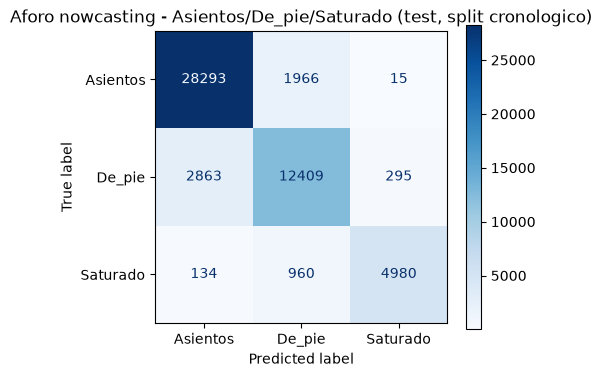

              precision    recall  f1-score   support

    Asientos      0.904     0.935     0.919     30274
      De_pie      0.809     0.797     0.803     15567
    Saturado      0.941     0.820     0.876      6074

    accuracy                          0.880     51915
   macro avg      0.885     0.851     0.866     51915
weighted avg      0.880     0.880     0.879     51915



In [23]:
# Aforo nowcasting honesto: misma etiqueta que el resto del notebook (Asientos/De_pie/Saturado),
# umbrales calibrados en train (cuantiles 0.6/0.9 de Ocupacion_real). Features calendario + estacion.
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

lo = dfm.loc[dfm["Fecha_Hora"] <= split, "Ocupacion_real"].quantile(0.6)
hi = dfm.loc[dfm["Fecha_Hora"] <= split, "Ocupacion_real"].quantile(0.9)
print("Umbrales (train): lo=%.3f hi=%.3f" % (lo, hi))

def clase_occ(v):
    if v > hi: return "Saturado"
    if v > lo: return "De_pie"
    return "Asientos"

enc_est_now = LabelEncoder().fit(df["Estacion"].unique())
clases_now = ["Asientos", "De_pie", "Saturado"]

dfn = dfm.dropna(subset=["Ocupacion_real"]).copy()
trn = dfn[dfn["Fecha_Hora"] <= split]
ten = dfn[dfn["Fecha_Hora"] > split]

def feats_now(frame):
    F = pd.DataFrame(index=frame.index)
    F["hora"] = frame["Fecha_Hora"].dt.hour
    F["sin_h"] = np.sin(2*np.pi*F["hora"]/24)
    F["cos_h"] = np.cos(2*np.pi*F["hora"]/24)
    F["dia"] = frame["Fecha_Hora"].dt.day
    F["Es_Habil"] = frame["Es_Habil"].astype(int)
    F["Estacion_cod"] = enc_est_now.transform(frame["Estacion"])
    return F

Xtr_n, ytr_n = feats_now(trn), trn["Ocupacion_real"].map(clase_occ).astype(str)
Xte_n, yte_n = feats_now(ten), ten["Ocupacion_real"].map(clase_occ).astype(str)

clf = RandomForestClassifier(n_estimators=250, random_state=0, n_jobs=-1)
clf.fit(Xtr_n, ytr_n)
yp_n = clf.predict(Xte_n)
print("Aforo nowcasting (calendario + estacion): Acc=%.3f" % accuracy_score(yte_n, yp_n))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(yte_n, yp_n, labels=clases_now, ax=ax,
                                        cmap="Blues", values_format="d")
ax.set_title("Aforo nowcasting - Asientos/De_pie/Saturado (test, split cronologico)")
plt.tight_layout(); plt.show()
print(classification_report(yte_n, yp_n, labels=clases_now, digits=3))


Ahora el clasificador de aforo usa la **misma etiqueta que el resto del notebook**: `Asientos` /
`De_pie` / `Saturado` con umbrales de ocupacion calibrados solo en train (cuantiles 0.6/0.9 de
`Ocupacion_real` en `dfm`), en lugar del `qcut` global de `Ocupacion_pk` que confundia Bajo con Alto.
Ademas de calendario (`hora` + seno/coseno, `dia`, `Es_Habil`) incluye **identidad de estacion**
(`Estacion_cod`): "Saturado" depende en gran parte de que la estacion sea de alta demanda, y esa era
la pieza que faltaba (antes acertaba pocos "Alto" y marcaba muchos falsos "Alto"). Con esto el falso
"Saturado" se reduce y la matriz queda coherente con el Modulo 2/3. Sigue siendo **nowcasting** (usa
ocupacion real en test), no pronostico: la version con features pronosticadas esta en el comparativo.


### 5. Modulo 2 - Aforo multiclase (comparativo de modelos)

Vamos a comparar clasificadores para el nivel de aforo (3 clases: Asientos / De pie / Saturado). Marco honesto:

- **Etiqueta**: derivada de `Ocupacion = Validaciones / Cap_total`, con umbrales ajustados **solo
  sobre entrenamiento** (split cronológico 2026-08-13).
- **Features**: calendario (hora + seno/coseno, día, día de la semana, hábil) + estación +
  **`Validaciones_pron` de Chronos** (sin fuga del día a evaluar).
- **Evaluación**: sobre los días de test (2026-08-14 en adelante) con Accuracy, Balanced Accuracy,
  F1-macro y ROC-AUC OvR; matriz de confusión para el mejor.


Umbrales (train): lo=1.479 hi=9.013
       modelo  accuracy  balanced_acc  f1_macro  roc_auc_ovr
5      HistGB    0.9447        0.9336    0.9408       0.9852
6    LightGBM    0.9422        0.9296    0.9373       0.9847
7     XGBoost    0.9422        0.9288    0.9372       0.9856
1        Tree    0.9361        0.9234    0.9302       0.9398
4          GB    0.9230        0.9030    0.9153       0.9809
2          RF    0.9159        0.8813    0.9014       0.9789
3  ExtraTrees    0.8969        0.8251    0.8578       0.9726
0    Logistic    0.8120        0.6324    0.6550       0.8851

Mejor por F1-macro: HistGB


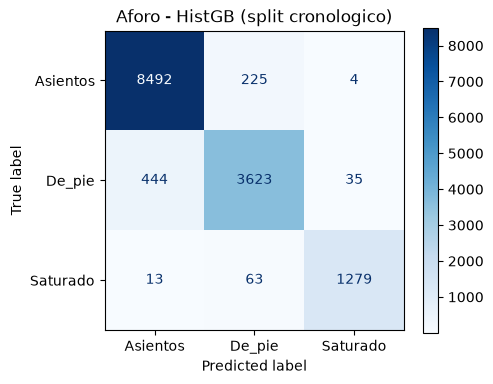

              precision    recall  f1-score   support

    Asientos      0.949     0.974     0.961      8721
      De_pie      0.926     0.883     0.904      4102
    Saturado      0.970     0.944     0.957      1355

    accuracy                          0.945     14178
   macro avg      0.949     0.934     0.941     14178
weighted avg      0.944     0.945     0.944     14178



In [24]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Etiqueta con umbrales calibrados solo en train 
tr_m2 = dfm[dfm["Fecha_Hora"] <= split].dropna(subset=["Ocupacion_real"]).copy()
lo, hi = tr_m2["Ocupacion_real"].quantile([0.6, 0.9])
def clase_occ(v):
    if v > hi: return "Saturado"
    if v > lo: return "De_pie"
    return "Asientos"
print("Umbrales (train): lo=%.3f hi=%.3f" % (lo, hi))

# Encoders (todas las estaciones del dataset)
enc_dia = LabelEncoder().fit(df2["DiaSemana"])
enc_est = LabelEncoder().fit(df["Estacion"].unique())

def feats_m2(frame, pron_val=None):
    F = pd.DataFrame(index=frame.index)
    F["hora"] = frame["Fecha_Hora"].dt.hour
    F["sin_h"] = np.sin(2*np.pi*F["hora"]/24)
    F["cos_h"] = np.cos(2*np.pi*F["hora"]/24)
    F["dia"] = frame["Fecha_Hora"].dt.day
    F["DiaSemana_cod"] = enc_dia.transform(frame["DiaSemana"])
    F["Es_Habil"] = frame["Es_Habil"].astype(int)
    F["Estacion_cod"] = enc_est.transform(frame["Estacion"])
    F["Validaciones_pron"] = (pron_val if pron_val is not None
                              else frame["Validaciones"].values)
    return F

# Train (datos observados como stand-in)
tr_m2b = dfm[dfm["Fecha_Hora"] <= split].dropna(subset=["Ocupacion_real"]).copy()
Xtr_m2 = feats_m2(tr_m2b)
ytr_m2 = tr_m2b["Ocupacion_real"].map(clase_occ).astype(str)

# subsample estratificado para velocidad
sub = train_test_split(Xtr_m2.reset_index(drop=True), ytr_m2.reset_index(drop=True),
                       train_size=25000, random_state=0,
                       stratify=ytr_m2.reset_index(drop=True))
Xtr_s, Xtr_rest, ytr_s, ytr_rest = sub

# Test: features pronosticadas (sin fuga)
pr_rows = []
for dia in dias_eval:
    posV, fcV = pronostica_dia(grid, dia, ok=estaciones_ok)
    for k, pos in enumerate(posV):
        e = estaciones_ok[pos]
        for j in range(24):
            pr_rows.append((dia + pd.Timedelta(hours=j), e, float(fcV[k, 4, j])))
prm = pd.DataFrame(pr_rows, columns=["Fecha_Hora", "Estacion", "vp"]).set_index(
    ["Estacion", "Fecha_Hora"])["vp"]

te_idx = dfm[dfm["Fecha_Hora"] > split].copy()
te_m2b = te_idx.dropna(subset=["Ocupacion_real"]).copy()
key = pd.MultiIndex.from_frame(te_m2b[["Estacion", "Fecha_Hora"]])
te_m2b = te_m2b[key.isin(prm.index)].copy()
te_m2b["Validaciones_pron"] = key[key.isin(prm.index)].map(prm).values
te_m2b = te_m2b.dropna(subset=["Validaciones_pron"])

Xte_m2 = feats_m2(te_m2b, pron_val=te_m2b["Validaciones_pron"].values)
yte_m2 = te_m2b["Ocupacion_real"].map(clase_occ).astype(str)

def build_models():
    MODS = {
        "Logistic": LogisticRegression(max_iter=2000),
        "Tree": DecisionTreeClassifier(random_state=0),
        "RF": RandomForestClassifier(n_estimators=200, random_state=0),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=200, random_state=0),
        "GB": GradientBoostingClassifier(random_state=0),
        "HistGB": HistGradientBoostingClassifier(random_state=0),
    }
    try:
        import lightgbm
        MODS["LightGBM"] = lightgbm.LGBMClassifier(random_state=0, verbose=-1)
    except Exception:
        pass
    try:
        import xgboost
        MODS["XGBoost"] = xgboost.XGBClassifier(random_state=0,
                                                eval_metric="logloss",
                                                tree_method="hist")
    except Exception:
        pass
    return MODS

MODELS2 = build_models()

clases = ["Asientos", "De_pie", "Saturado"]
le_y = LabelEncoder().fit(clases)
ytr2n = le_y.transform(pd.Series(ytr_s, dtype=object))
yte2n = le_y.transform(pd.Series(yte_m2, dtype=object))
filas2, fit2 = [], {}
for nombre, mdl in MODELS2.items():
    mdl.fit(Xtr_s, ytr2n)
    yp = le_y.inverse_transform(mdl.predict(Xte_m2))
    auc = np.nan
    if hasattr(mdl, "predict_proba"):
        probs = mdl.predict_proba(Xte_m2)
        col = [list(mdl.classes_).index(c) for c in range(3)]
        auc = roc_auc_score(yte2n, probs[:, col], multi_class="ovr")
    filas2.append({"modelo": nombre,
                   "accuracy": accuracy_score(yte_m2, yp),
                   "balanced_acc": balanced_accuracy_score(yte_m2, yp),
                   "f1_macro": f1_score(yte_m2, yp, average="macro", labels=clases),
                   "roc_auc_ovr": auc})
    fit2[nombre] = (mdl, yp)

cmp2 = pd.DataFrame(filas2).sort_values("f1_macro", ascending=False)
cmp2.to_csv(MODEL_OUT / "comparativa_aforo_modelos.csv", index=False)
print(cmp2.round(4).to_string())
best2 = cmp2.iloc[0]["modelo"]
print("\nMejor por F1-macro:", best2)

mdl_b, yp_b = fit2[best2]
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(yte_m2, yp_b, labels=clases, ax=ax,
                                        cmap="Blues", values_format="d")
ax.set_title(f"Aforo - {best2} (split cronologico)")
plt.tight_layout(); plt.show()
print(classification_report(yte_m2, yp_b, labels=clases, digits=3))


### 6. Modulo 3 - Recomendacion prescriptiva (comparativo)

Vamos a resolver la clasificación de las 3 clases (Abordar/Esperar siguiente/Cambiar de paradero). La "verdad" la define una **matriz de decisión U(ETA, Aforo)** explícita y calibratable:

- ETA >= 10 min -> Cambiar de paradero (esperar más de 10 min no vale la pena).
- ETA < 10 min y unidad saturada -> Esperar siguiente SOLO si el siguiente bus no viene
  saturado (se verifica su ocupaci\u00f3n pronosticada de la pr\u00f3xima hora); si el siguiente
  tambi\u00e9n viene lleno -> Cambiar de paradero.
- ETA < 10 min y no saturada -> Abordar.

Se entrenan clasificadores para **preservar esa lógica** a partir de features pronosticadas
(`eta_pron` del mejor de 4.2, `occ_pron` de Chronos) + calendario. Métricas: fidelidad vs matriz
(AC-03>=80%), F1-macro y penalización de **FP de Abordar**.


In [25]:

def decision_u(eta_min, clase, next_clase=None):
    if eta_min != eta_min: return np.nan
    if eta_min >= 10.0: return "cambiar_paradero"
    if clase == "Saturado":
        if next_clase is not None and next_clase != "Saturado":
            return "esperar_siguiente"
        return "cambiar_paradero"
    return "abordar"

# Ffeatures y target (train usa valores reales como pronostico del pasado)
def build_m3(frame, eta_map=None, occ_map=None, occ_map_next=None):
    F = pd.DataFrame(index=frame.index)
    F["hora"] = frame["Fecha_Hora"].dt.hour
    F["dia"] = frame["Fecha_Hora"].dt.day
    F["DiaSemana_cod"] = enc_dia.transform(frame["DiaSemana"])
    F["Es_Habil"] = frame["Es_Habil"].astype(int)
    F["Estacion_cod"] = enc_est.transform(frame["Estacion"])
    if eta_map is not None:
        F["eta_pron"] = [eta_map.get((e, ts), np.nan)
                         for e, ts in zip(frame["Estacion"], frame["Fecha_Hora"])]
    else:
        F["eta_pron"] = frame["Headway_Min"].fillna(frame["Headway_Min"].median()).values
    if occ_map is not None:
        F["occ_pron"] = [occ_map.get((e, ts), np.nan)
                         for e, ts in zip(frame["Estacion"], frame["Fecha_Hora"])]
    else:
        F["occ_pron"] = frame["Ocupacion_real"].values
    if occ_map_next is not None:
        F["occ_next"] = [occ_map_next.get((e, ts + pd.Timedelta(hours=1)), np.nan)
                         for e, ts in zip(frame["Estacion"], frame["Fecha_Hora"])]
    else:
        onxt = {(e, ts): v for e, ts, v in
                zip(frame["Estacion"], frame["Fecha_Hora"], frame["Ocupacion_real"])}
        F["occ_next"] = [onxt.get((e, ts + pd.Timedelta(hours=1)), np.nan)
                         for e, ts in zip(frame["Estacion"], frame["Fecha_Hora"])]
    F = F.dropna()
    # la decision usa el nivel del bus actual y del siguiente (llegada prox. ~ +1h)
    y = [decision_u(e, clase_occ(o), None if n != n else clase_occ(n))
         for e, o, n in zip(F["eta_pron"], F["occ_pron"], F["occ_next"])]
    return F, pd.Series(y, index=F.index)

tr_m3 = dfm[dfm["Fecha_Hora"] <= split].dropna(subset=["Ocupacion_real", "Headway_Min"]).copy()
Xtr_m3, ytr_m3 = build_m3(tr_m3)
sub3 = train_test_split(Xtr_m3.reset_index(drop=True), ytr_m3.reset_index(drop=True),
                        train_size=25000, random_state=0, stratify=ytr_m3.reset_index(drop=True))
Xtr3, _, ytr3, _ = sub3

# Test: features pronosticadas (de los forecasts de 4.2/4.3)
eta_map, occ_map = {}, {}
for dia in dias_eval:
    posV, fcV = pronostica_dia(grid, dia, ok=estaciones_ok)
    for k, pos in enumerate(posV):
        e = estaciones_ok[pos]
        cap = cap_map.get(e, np.nan)
        for j in range(25):
            occ_map[(e, dia + pd.Timedelta(hours=j))] = fcV[k, 4, j] / cap if (j < 24 and cap == cap and cap > 0) else np.nan
    # eta pron por HORA = headway pronosticado (opcion A de 4.2, base del blend)
    posA, fcA = pronostica_dia(hgrid, dia, ok=estaciones_ok)
    for k, pos in enumerate(posA):
        e = estaciones_ok[pos]
        for j in range(24):
            eta_map[(e, dia + pd.Timedelta(hours=j))] = float(fcA[k, 4, j])

te_m3 = dfm[dfm["Fecha_Hora"] > split].dropna(subset=["Ocupacion_real", "Headway_Min"]).copy()
Xte3, yte3 = build_m3(te_m3, eta_map=eta_map, occ_map=occ_map, occ_map_next=occ_map)

cla = ["abordar", "esperar_siguiente", "cambiar_paradero"]
MODELS3_objs = build_models()   # instancias NUEVAS (evita bugs de refit en XGBoost)
le_y3 = LabelEncoder().fit(cla)
ytr3n = le_y3.transform(pd.Series(ytr3, dtype=object))
yte3n = le_y3.transform(pd.Series(yte3, dtype=object))
filas3, fit3 = [], {}
for nombre, mdl in MODELS3_objs.items():
    mdl.fit(Xtr3, ytr3n)
    yp = le_y3.inverse_transform(mdl.predict(Xte3))
    fp_abord = np.mean([(p == "abordar") and (t != "abordar") for p, t in zip(yp, yte3)])
    filas3.append({"modelo": nombre,
                   "fidelidad_AC03": accuracy_score(yte3, yp),
                   "f1_macro": f1_score(yte3, yp, average="macro", labels=cla),
                   "fp_abordar": fp_abord})
    fit3[nombre] = (mdl, yp)

cmp3 = pd.DataFrame(filas3).sort_values("fidelidad_AC03", ascending=False)
cmp3.to_csv(MODEL_OUT / "comparativa_modulo3_modelos.csv", index=False)
print(cmp3.round(4).to_string())
print("\nMejor por fidelidad AC-03:", cmp3.iloc[0]["modelo"])
print("\nDistribucion de la matriz (test):")
print(pd.Series(yte3).value_counts().to_string())
print()
print(classification_report(yte3, fit3[cmp3.iloc[0]['modelo']][1], digits=3))


       modelo  fidelidad_AC03  f1_macro  fp_abordar
1        Tree          0.9997    0.9977      0.0000
2          RF          0.9997    0.9977      0.0000
4          GB          0.9997    0.9977      0.0000
5      HistGB          0.9992    0.9817      0.0005
7     XGBoost          0.9987    0.9611      0.0006
6    LightGBM          0.9975    0.9364      0.0005
0    Logistic          0.9961    0.8819      0.0016
3  ExtraTrees          0.9960    0.8886      0.0013

Mejor por fidelidad AC-03: Tree

Distribucion de la matriz (test):
abordar              11999
cambiar_paradero       293
esperar_siguiente       66

                   precision    recall  f1-score   support

          abordar      1.000     1.000     1.000     11999
 cambiar_paradero      0.987     1.000     0.993       293
esperar_siguiente      1.000     1.000     1.000        66

         accuracy                          1.000     12358
        macro avg      0.996     1.000     0.998     12358
     weighted avg      1.0

---
### 7. Anomalias (Modulo 4) - deteccion no supervisada sobre contexto

Vamos hacer la **deteccion no supervisada de anomalias**. Aqui se entrena **IsolationForest** **solo sobre datos de contexto** (entrenamiento <= `split`) y se aplica a las observaciones reales del test para detectar la semana "anomala" del 2026-08-14 en adelante, sin que el modelo haya visto esos dias.

**Importante**: esta seccion **no** mezcla TomTom en el entrenamiento. La capa de datos en vivo de
TomTom se implementa en despliegue como una senal adicional, nunca en ajuste.


In [26]:
from sklearn.ensemble import IsolationForest

cols_iso = ["Validaciones", "Frecuencia", "Headway_Min", "N_Rutas", "hora", "dia"]
Xctx = df2[df2["Fecha_Hora"] <= split][cols_iso].fillna(0)
Xte_f = df2[df2["Fecha_Hora"] > split][cols_iso].fillna(0)

ifo = IsolationForest(contamination=0.05, random_state=0, n_jobs=-1)
ifo.fit(Xctx)
score_te = ifo.score_samples(Xte_f).reshape(-1)
df2_te = df2[df2["Fecha_Hora"] > split].copy()
df2_te["anomaly_score"] = score_te
df2_te["outlier"] = (score_te < ifo.offset_).astype(int)

thresholds = np.percentile(score_te, [0.5, 3.0])
print("Umbrales detectados (p0.5, p3.0):", thresholds.round(3))
print("Fraccion bajo umbral (esperado ~0.005 / ~0.03):",
      (score_te < thresholds[0]).mean().round(4), (score_te < thresholds[1]).mean().round(4))
print("\nOutliers por dia (promedio 0..1):")
print(df2_te.set_index("Fecha_Hora")["outlier"].resample("D").mean().round(3).to_string())


Umbrales detectados (p0.5, p3.0): [-0.686 -0.605]
Fraccion bajo umbral (esperado ~0.005 / ~0.03): 0.005 0.03

Outliers por dia (promedio 0..1):
Fecha_Hora
2026-08-14    0.057
2026-08-15    0.037
2026-08-16    0.015
2026-08-17    0.014
2026-08-18    0.061
2026-08-19    0.062
2026-08-20    0.062
2026-08-21    0.066
2026-08-22    0.041
2026-08-23    0.024
2026-08-24    0.072
2026-08-25    0.074
2026-08-26    0.068
2026-08-27    0.069
2026-08-28    0.072
2026-08-29    0.069
2026-08-30    0.045
2026-08-31    0.095
Freq: D


El IsolationForest asigna un `anomaly_score` por registro del test (2026-08-14 al 31). Los umbrales p0.5/p3.0 definen que tan extremo es el evento. La columna `outlier` flaggea los registros anomalos, y la agregacion diaria revela que dias se desvian del patron historico (demanda anomala).

Sin clave TomTom la funcion devuelve `None` y el sistema opera en **Modo Historico** (RF-05): exactamente el flujo que acabamos de implementar con la tabla de headways y el pronostico. Con clave, en produccion, se consultaria el flujo real por estacion para recalibrar ETA y aforo en tiempo real sin reentrenar el modelo.

### 9. Conclusiones

1. **Nowcasting vs pronostico**: los baselines de ML (Seccion 3) son nowcasting honesto; el
   **pronostico real** lo entrega Chronos en walk-forward (Seccion 2), sin datos futuros.
2. **Chronos > baselines**: `amazon/chronos-bolt-small` supera a `naive_24` y `hora_media` en MAE,
   RMSE y WMAPE en la evaluacion de 5 dias (2026-08-14/15/16/21/29); pinball bien calibrado.
3. **ETA (Modulo 1)**: se compararon 4 opciones en walk-forward por hora sobre 5 dias
   (A=Chronos Headway, B=tabla historica x ocupacion, C=blend, D=blend x ratio de congestion
   sintetica). Ganador: **C_blend** (MAE 0.244 vs A 0.245 / B 0.304). La ablacion muestra que el
   ratio sintetico TomTom **no aporta** (D empeora: MAE 0.418), por lo que queda desactivado en esta
   iteracion; con datos reales de produccion (S08) se debe re-evaluar. Detalle por dia en
   `eta_comparativa_modelos.csv`.
4. **Aforo (Modulo 2)**: comparativo de clasificadores (logistico, arbol, RF, ExtraTrees, GB,
   HistGB, LightGBM, XGBoost) con split cronologico; se eligio por F1-macro y Balanced Accuracy
   (`comparativa_aforo_modelos.csv`). Sin features climaticas (EDA las descarto).
5. **Prescriptivo (Modulo 3)**: comparativo de clasificadores que preservan la matriz de decision
   U(ETA, Aforo) rebajada a umbral 10 min con chequeo del siguiente bus (esperar siguiente solo si
   el proximo no viene saturado; si viene lleno -> cambiar). Fidelidad AC-03 y FP de "abordar" en
   `comparativa_modulo3_modelos.csv`.
6. **Modulo 4**: IsolationForest detecta anomalias sobre contexto (p0.5/p3.0).
